In [ ]:
#Roll no: 24BAD008
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Raw_Sales_Data.csv')

# introduce messiness for the assignment
np.random.seed(1)

# a. missing values
missing_idx = np.random.choice(df.index, 15, replace=False)
df.loc[missing_idx, 'Sales'] = np.nan

# b. an obvious outlier
outlier_idx = np.random.choice(df.index, 2, replace=False)
df.loc[outlier_idx, 'Sales'] = df['Sales'].max() * 50

# c. inconsistent date format (mix in DD/MM/YYYY among the default YYYY-MM-DD)
mixed_idx = np.random.choice(df.index, 20, replace=False)
df.loc[mixed_idx, 'OrderDate'] = pd.to_datetime(df.loc[mixed_idx, 'OrderDate']).dt.strftime('%d/%m/%Y')

df.to_csv('/content/messy_sales.csv', index=False)
print("Messy dataset created:", df.shape)

Messy dataset created: (3000, 10)


## Step 1: Load Messy Dataset

In [ ]:
df = pd.read_csv('/content/messy_sales.csv')
df.head(10)

,OrderID,OrderDate,Region,Country,Category,Product,Salesperson,Quantity,UnitPrice,Sales
0,1000,2024-10-16,North America,USA,Stationery,Pen Set,F. Dubois,4,7.65,30.60
1,1001,2023-04-15,Asia,Japan,Stationery,Notebook,A. Rao,10,3.02,30.20
2,1002,2023-04-06,North America,USA,Stationery,Whiteboard,F. Dubois,1,62.42,62.42
3,1003,2024-10-27,Asia,Japan,Furniture,Office Chair,A. Rao,8,157.10,1256.80
4,1004,2023-06-13,Asia,China,Furniture,Desk,C. Smith,3,209.84,629.52
5,1005,2023-04-15,North America,Canada,Electronics,Headphones,C. Smith,14,78.88,1104.32
6,1006,2023-02-14,Asia,China,Stationery,Notebook,E. Tanaka,15,2.98,44.70
7,1007,2023-10-28,Asia,Japan,Furniture,Bookshelf,A. Rao,4,107.61,430.44
8,1008,2024-11-08,North America,Canada,Electronics,Smartphone,C. Smith,14,462.63,6476.82
9,1009,2024-04-09,Asia,China,Electronics,Headphones,C. Smith,6,76.19,457.14


## Step 2: Handle Missing Values in 'Sales' Column

In [ ]:
# Check for missing values in the 'Sales' column before imputation
print("Missing 'Sales' values before imputation:")
display(df['Sales'].isnull().sum())

# Calculate the median Sales for each Category
median_sales_by_category = df.groupby('Category')['Sales'].median()

# Impute missing Sales values using the median Sales for each Category
df['Sales'] = df.apply(
    lambda row: median_sales_by_category[row['Category']] if pd.isnull(row['Sales']) else row['Sales'],
    axis=1
)

# Check for missing values in the 'Sales' column after imputation
print("\nMissing 'Sales' values after imputation:")
display(df['Sales'].isnull().sum())

# Display the first few rows to show the imputed values (if any were in the head)
display(df.head(10))

Missing 'Sales' values before imputation:


np.int64(15)


Missing 'Sales' values after imputation:


np.int64(0)

,OrderID,OrderDate,Region,Country,Category,Product,Salesperson,Quantity,UnitPrice,Sales
0,1000,2024-10-16,North America,USA,Stationery,Pen Set,F. Dubois,4,7.65,30.60
1,1001,2023-04-15,Asia,Japan,Stationery,Notebook,A. Rao,10,3.02,30.20
2,1002,2023-04-06,North America,USA,Stationery,Whiteboard,F. Dubois,1,62.42,62.42
3,1003,2024-10-27,Asia,Japan,Furniture,Office Chair,A. Rao,8,157.10,1256.80
4,1004,2023-06-13,Asia,China,Furniture,Desk,C. Smith,3,209.84,629.52
5,1005,2023-04-15,North America,Canada,Electronics,Headphones,C. Smith,14,78.88,1104.32
6,1006,2023-02-14,Asia,China,Stationery,Notebook,E. Tanaka,15,2.98,44.70
7,1007,2023-10-28,Asia,Japan,Furniture,Bookshelf,A. Rao,4,107.61,430.44
8,1008,2024-11-08,North America,Canada,Electronics,Smartphone,C. Smith,14,462.63,6476.82
9,1009,2024-04-09,Asia,China,Electronics,Headphones,C. Smith,6,76.19,457.14


## Step 3: Detect and Cap Outliers in 'Sales' using IQR

In [ ]:
# Calculate Q1, Q3, and IQR for the 'Sales' column
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

# Define the upper bound for outliers
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_before_capping = df[df['Sales'] > upper_bound]
print(f"Number of outliers in 'Sales' before capping: {len(outliers_before_capping)}")

# Cap outliers at the upper bound
df['Sales'] = np.where(df['Sales'] > upper_bound, upper_bound, df['Sales'])

# Verify if outliers are capped
outliers_after_capping = df[df['Sales'] > upper_bound]
print(f"Number of outliers in 'Sales' after capping: {len(outliers_after_capping)}")

# Display the rows that previously contained outliers to see the capped values
# We'll re-check the original outlier indices or a sample that had high values
print("\nSales values for previously identified outlier rows (capped):")
# For demonstration, we can show a general head or tail, or if we had original outlier indices, show those.
# Since we didn't store the exact indices of the original outliers before capping,
# we'll just display a sample of the dataframe to illustrate the change.
display(df.sort_values(by='Sales', ascending=False).head(10))

Number of outliers in 'Sales' before capping: 249
Number of outliers in 'Sales' after capping: 0

Sales values for previously identified outlier rows (capped):


,OrderID,OrderDate,Region,Country,Category,Product,Salesperson,Quantity,UnitPrice,Sales
2948,3948,2023-10-03,Asia,China,Electronics,Laptop,B. Chen,6,874.60,4944.1475
8,1008,2024-11-08,North America,Canada,Electronics,Smartphone,C. Smith,14,462.63,4944.1475
2932,3932,2024-11-06,Asia,China,Electronics,Tablet,E. Tanaka,15,331.27,4944.1475
2997,3997,2024-12-04,Asia,India,Electronics,Laptop,C. Smith,7,863.42,4944.1475
2977,3977,2024-08-30,Europe,France,Electronics,Laptop,F. Dubois,8,771.29,4944.1475
1094,2094,2024-10-05,North America,USA,Electronics,Laptop,F. Dubois,14,733.65,4944.1475
2965,3965,2023-11-23,Europe,France,Electronics,Laptop,B. Chen,14,835.60,4944.1475
2982,3982,2023-07-27,Europe,France,Electronics,Smartphone,A. Rao,15,546.31,4944.1475
1126,2126,2023-10-12,Asia,Japan,Electronics,Laptop,A. Rao,12,817.17,4944.1475
2372,3372,2024-11-14,North America,Mexico,Electronics,Laptop,A. Rao,8,822.68,4944.1475


## Step 4: Parse 'OrderDate' with Mixed Formats

In [ ]:
# Before parsing, check the current data type of 'OrderDate'
print("Original 'OrderDate' dtype (as it currently exists in df):", df['OrderDate'].dtype)
print("Number of NaT values before re-parsing:", df['OrderDate'].isnull().sum())
print("Sample of 'OrderDate' before parsing:")
display(df['OrderDate'].head(10))

# Re-read only the 'OrderDate' column from the original messy_sales.csv as strings
# This ensures we get the original mixed string formats, not pre-parsed datetimes or NaTs.
original_order_dates_str = pd.read_csv('/content/messy_sales.csv', dtype={'OrderDate': str})['OrderDate']

def parse_mixed_date(date_str):
    if pd.isna(date_str): # Handles NaN from pd.read_csv if any, or original NaT strings
        return pd.NaT
    date_str = str(date_str) # Ensure it's a string for parsing
    try:
        # Try parsing as DD/MM/YYYY (which are the mixed-in dates)
        return pd.to_datetime(date_str, format='%d/%m/%Y', errors='raise')
    except (ValueError, TypeError): # Catch both ValueError for format and TypeError if it's not a string
        try:
            # If that fails, try parsing as YYYY-MM-DD (the default format)
            return pd.to_datetime(date_str, format='%Y-%m-%d', errors='raise')
        except (ValueError, TypeError):
            # If both fail, return NaT
            return pd.NaT

# Apply the custom parsing function to the re-read string column
df['OrderDate'] = original_order_dates_str.apply(parse_mixed_date)

# Check for any dates that couldn't be parsed after the custom function
unparsed_dates = df['OrderDate'].isnull().sum()
if unparsed_dates > 0:
    print(f"\nWarning: {unparsed_dates} dates could not be parsed and were converted to NaT.")
    # Optionally, display rows with unparsed dates
    # display(df[df['OrderDate'].isnull()])
else:
    print("\nAll 'OrderDate' values successfully parsed.")

# Verify the new data type and display a sample of the cleaned column
print("\nUpdated 'OrderDate' dtype:", df['OrderDate'].dtype)
print("Sample of 'OrderDate' after parsing:")
display(df['OrderDate'].head(10))

# Display the info of the DataFrame to confirm the column type change
print("\nDataFrame Info after OrderDate parsing:")
df.info()

Original 'OrderDate' dtype (as it currently exists in df): datetime64[ns]
Number of NaT values before re-parsing: 20
Sample of 'OrderDate' before parsing:


,OrderDate
0,2024-10-16
1,2023-04-15
2,2023-04-06
3,2024-10-27
4,2023-06-13
5,2023-04-15
6,2023-02-14
7,2023-10-28
8,2024-11-08
9,2024-04-09



All 'OrderDate' values successfully parsed.

Updated 'OrderDate' dtype: datetime64[ns]
Sample of 'OrderDate' after parsing:


,OrderDate
0,2024-10-16
1,2023-04-15
2,2023-04-06
3,2024-10-27
4,2023-06-13
5,2023-04-15
6,2023-02-14
7,2023-10-28
8,2024-11-08
9,2024-04-09



DataFrame Info after OrderDate parsing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   OrderID      3000 non-null   int64         
 1   OrderDate    3000 non-null   datetime64[ns]
 2   Region       3000 non-null   object        
 3   Country      3000 non-null   object        
 4   Category     3000 non-null   object        
 5   Product      3000 non-null   object        
 6   Salesperson  3000 non-null   object        
 7   Quantity     3000 non-null   int64         
 8   UnitPrice    3000 non-null   float64       
 9   Sales        3000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 234.5+ KB


## Step 5: Visualize the Cleaned 'Sales' Distribution

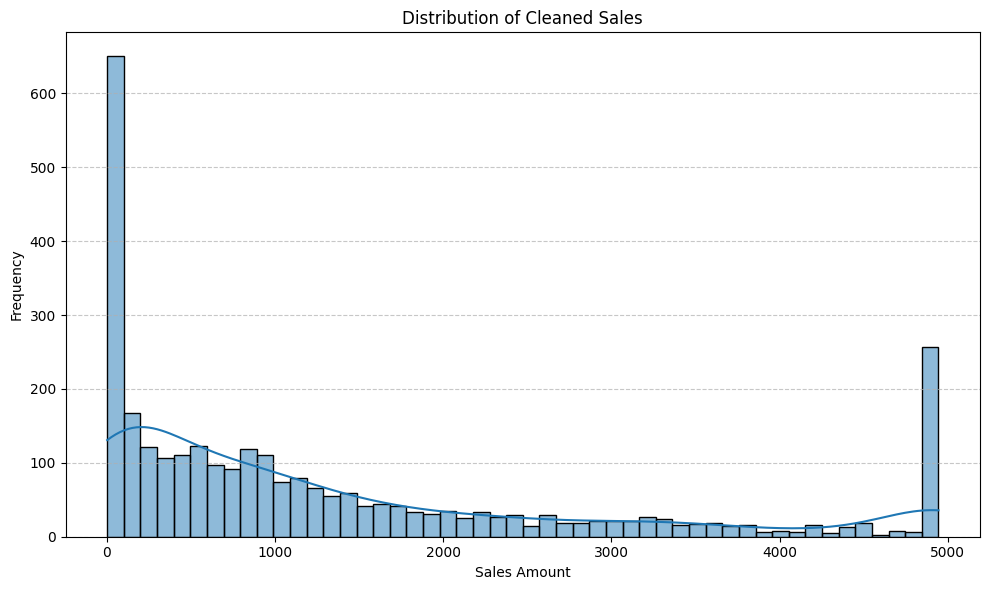

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot a histogram of the cleaned 'Sales' column
fig = plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], bins=50, kde=True)
plt.title('Distribution of Cleaned Sales')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
df['Year'] = df['OrderDate'].dt.year
df['Quarter'] = df['OrderDate'].dt.quarter

In [ ]:
df_aggregated = df.groupby(['Region', 'Year', 'Quarter', 'Category'])['Sales'].sum().reset_index(name='Sales_Amount')
display(df_aggregated.head())

,Region,Year,Quarter,Category,Sales_Amount
0,Asia,2023,1,Electronics,122446.3325
1,Asia,2023,1,Furniture,49952.8475
2,Asia,2023,1,Stationery,8254.2800
3,Asia,2023,2,Electronics,113780.5375
4,Asia,2023,2,Furniture,57387.0500


In [ ]:
# Ensure the DataFrame is sorted by Region, Year, Quarter, and Category for correct analytical calculations
df_aggregated = df_aggregated.sort_values(by=['Region', 'Year', 'Quarter', 'Category']).reset_index(drop=True)

# 1) Sales_Rank: Dense rank of Sales_Amount within each Year+Quarter (highest sales = rank 1)
# This is equivalent to SQL's DENSE_RANK() OVER (PARTITION BY Region, Year, Quarter ORDER BY Sales_Amount DESC)
df_aggregated['Sales_Rank'] = df_aggregated.groupby(['Region', 'Year', 'Quarter'])['Sales_Amount'].rank(method='dense', ascending=False)

# 2) Prior_Period_Sales: Sales_Amount from the previous period for the same Region and Category
# This is equivalent to SQL's LAG(Sales_Amount, 1) OVER (PARTITION BY Region, Category ORDER BY Year, Quarter)
df_aggregated['Prior_Period_Sales'] = df_aggregated.groupby(['Region', 'Category'])['Sales_Amount'].shift(1)

# 3) Running_Total: Cumulative sum of Sales_Amount per Region over time
# This is equivalent to SQL's SUM(Sales_Amount) OVER (PARTITION BY Region ORDER BY Year, Quarter ROWS UNBOUNDED PRECEDING)
df_aggregated['Running_Total'] = df_aggregated.groupby('Region')['Sales_Amount'].cumsum()

display(df_aggregated.head(10))

,Region,Year,Quarter,Category,Sales_Amount,Sales_Rank,Prior_Period_Sales,Running_Total
0,Asia,2023,1,Electronics,122446.3325,1.0,NaN,122446.3325
1,Asia,2023,1,Furniture,49952.8475,2.0,NaN,172399.1800
2,Asia,2023,1,Stationery,8254.2800,3.0,NaN,180653.4600
3,Asia,2023,2,Electronics,113780.5375,1.0,122446.3325,294433.9975
4,Asia,2023,2,Furniture,57387.0500,2.0,49952.8475,351821.0475
5,Asia,2023,2,Stationery,5478.5300,3.0,8254.2800,357299.5775
6,Asia,2023,3,Electronics,95089.8975,1.0,113780.5375,452389.4750
7,Asia,2023,3,Furniture,65475.9100,2.0,57387.0500,517865.3850
8,Asia,2023,3,Stationery,6685.0200,3.0,5478.5300,524550.4050
9,Asia,2023,4,Electronics,124945.1625,1.0,95089.8975,649495.5675


In [ ]:
# Ensure the DataFrame is sorted by Region, Year, Quarter, and Category for correct analytical calculations
df_aggregated = df_aggregated.sort_values(by=['Region', 'Year', 'Quarter', 'Category']).reset_index(drop=True)

# 1) Sales_Rank: Dense rank of Sales_Amount within each Year+Quarter (highest sales = rank 1)
# This is equivalent to SQL's DENSE_RANK() OVER (PARTITION BY Region, Year, Quarter ORDER BY Sales_Amount DESC)
df_aggregated['Sales_Rank'] = df_aggregated.groupby(['Region', 'Year', 'Quarter'])['Sales_Amount'].rank(method='dense', ascending=False)

# 2) Prior_Period_Sales: Sales_Amount from the previous period for the same Region and Category
# This is equivalent to SQL's LAG(Sales_Amount, 1) OVER (PARTITION BY Region, Category ORDER BY Year, Quarter)
df_aggregated['Prior_Period_Sales'] = df_aggregated.groupby(['Region', 'Category'])['Sales_Amount'].shift(1)

# 3) Running_Total: Cumulative sum of Sales_Amount per Region over time
# This is equivalent to SQL's SUM(Sales_Amount) OVER (PARTITION BY Region ORDER BY Year, Quarter ROWS UNBOUNDED PRECEDING)
df_aggregated['Running_Total'] = df_aggregated.groupby('Region')['Sales_Amount'].cumsum()

display(df_aggregated.head(10))

,Region,Year,Quarter,Category,Sales_Amount,Sales_Rank,Prior_Period_Sales,Running_Total
0,Asia,2023,1,Electronics,122446.3325,1.0,NaN,122446.3325
1,Asia,2023,1,Furniture,49952.8475,2.0,NaN,172399.1800
2,Asia,2023,1,Stationery,8254.2800,3.0,NaN,180653.4600
3,Asia,2023,2,Electronics,113780.5375,1.0,122446.3325,294433.9975
4,Asia,2023,2,Furniture,57387.0500,2.0,49952.8475,351821.0475
5,Asia,2023,2,Stationery,5478.5300,3.0,8254.2800,357299.5775
6,Asia,2023,3,Electronics,95089.8975,1.0,113780.5375,452389.4750
7,Asia,2023,3,Furniture,65475.9100,2.0,57387.0500,517865.3850
8,Asia,2023,3,Stationery,6685.0200,3.0,5478.5300,524550.4050
9,Asia,2023,4,Electronics,124945.1625,1.0,95089.8975,649495.5675
